## View preprocessed imgs

In [1]:
import sys
sys.path.append('/users/egottfri/code/octa-segmentation/src')

import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from preprocess import preprocess_directory

ROSE1 = Path("/files22_lrsresearch/ENG_Lee-Lab_Shared/group/data/public/rose_dataset/ROSE-1")
PREP_OUT = Path("/users/egottfri/code/octa-segmentation/data/preprocessed")

# Preprocess SVC train + test with optimal params (clip=2.0, tile=4)
for split in ["train", "test"]:
    preprocess_directory(
        input_dir=ROSE1 / f"SVC/{split}/img",
        output_dir=PREP_OUT / f"SVC/{split}/img",
        clip_limit=2.0, tile_size=4, kernel_size=3
    )

Processing 30 images from img...
Done! Saved to /users/egottfri/code/octa-segmentation/data/preprocessed/SVC/train/img
Processing 9 images from img...
Done! Saved to /users/egottfri/code/octa-segmentation/data/preprocessed/SVC/test/img


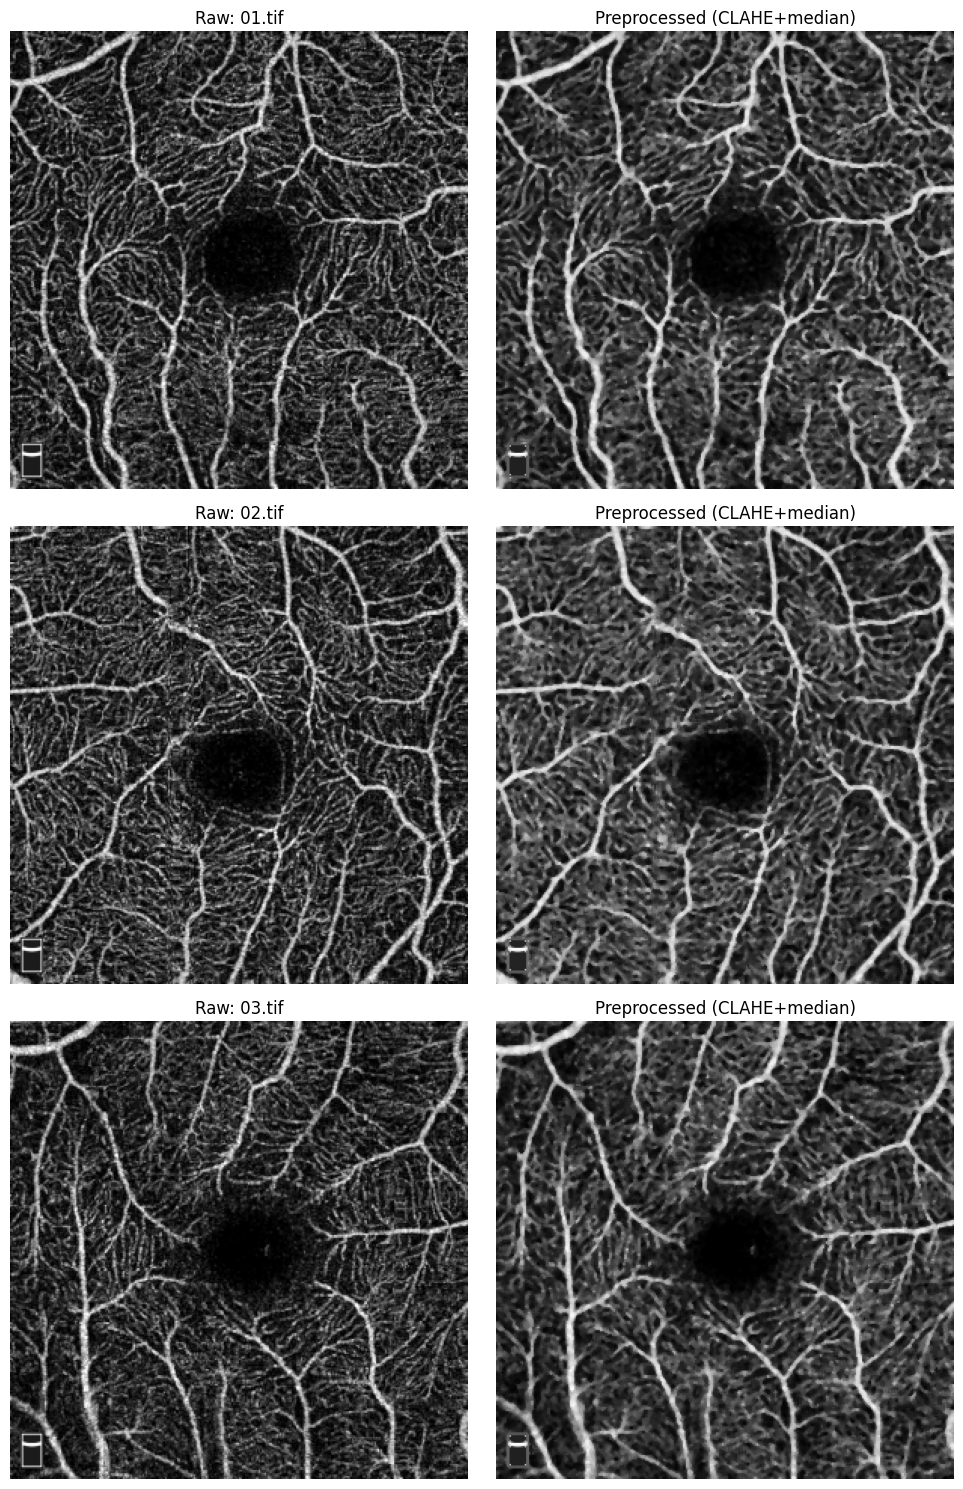

In [8]:
raw_imgs  = sorted((ROSE1 / "SVC/train/img").glob("*.tif"))
prep_imgs = sorted((PREP_OUT / "SVC/train/img").glob("*.tif"))

n_show = 3
fig, axes = plt.subplots(n_show, 2, figsize=(10, 5*n_show))
for i in range(n_show):
    raw  = cv2.imread(str(raw_imgs[i]),  cv2.IMREAD_GRAYSCALE)
    prep = cv2.imread(str(prep_imgs[i]), cv2.IMREAD_GRAYSCALE)
    axes[i, 0].imshow(raw,  cmap='gray'); axes[i, 0].set_title(f"Raw: {raw_imgs[i].name}")
    axes[i, 1].imshow(prep, cmap='gray'); axes[i, 1].set_title("Preprocessed (CLAHE+median)")
    axes[i, 0].axis('off'); axes[i, 1].axis('off')
plt.tight_layout()
plt.show()